In [23]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
current_dir = Path.cwd()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done")

In [25]:
# let's make a mixture of 1d normal and 1d exponential distribution
MEAN=100
STD=20
SIZE=1000
EXP_SCALE=20 
PRIOR=0.5
data = pd.DataFrame()
data["normal"] = np.random.normal(loc=MEAN, scale=STD, size=SIZE)
data["exp"] = np.random.exponential(scale=EXP_SCALE,size=SIZE)

In [26]:
data.head()

,normal,exp
0,135.602830,19.768499
1,94.599337,48.230569
2,90.895783,39.567350
3,110.182110,62.952549
4,64.185328,1.680768


In [27]:
def normal_pdf(x:float, mean:float, var:float) -> float:
    num = np.exp(-0.5*((x-mean)**2/(var + 1e-15)))
    deno = np.sqrt(2*np.pi*var)
    return num/deno

In [ ]:
def exponential_pdf(x, scale):
    scale = max(scale, 1e-15) 
    pdf_values = np.zeros_like(x, dtype=float)
    mask = x > 0
    pdf_values[mask] = (1.0 / scale) * np.exp(-x[mask] / scale)
    return pdf_values + 1e-15

In [29]:
exponential_pdf(x=data['normal'], scale=EXP_SCALE)

array([5.68057053e-05, 4.41338182e-04, 5.31120606e-04, 2.02486415e-04,
       2.01931144e-03, 3.64573447e-05, 4.15075788e-04, 1.22903337e-03,
       9.63671834e-05, 7.92606692e-05, 1.96959175e-04, 5.87738415e-05,
       2.15298297e-04, 3.94676367e-04, 1.70642918e-03, 2.50883267e-04,
       7.45491536e-04, 3.23634833e-04, 3.22821526e-04, 1.32496070e-04,
       1.21415887e-04, 1.10628137e-03, 4.67386949e-05, 9.79490504e-04,
       3.37865028e-04, 1.02352109e-03, 1.41720233e-04, 4.30926718e-04,
       4.93489092e-04, 8.25001936e-05, 2.86471522e-04, 1.35470101e-04,
       3.32601079e-04, 4.16453008e-04, 8.68828780e-05, 1.62712287e-04,
       2.53662575e-04, 1.74351061e-04, 2.08102974e-03, 3.21610051e-04,
       6.78195641e-04, 5.20213989e-04, 1.75286248e-04, 5.82169814e-04,
       2.08204262e-04, 1.21046679e-03, 9.48153563e-05, 3.19706055e-04,
       1.77568586e-04, 2.08682611e-04, 2.69077200e-04, 9.62372053e-04,
       3.37319349e-04, 2.40170170e-04, 8.01913636e-05, 2.02943117e-04,
      

In [30]:
def multimodel_single_dim(x: pd.DataFrame, prior: float, iterations: int = 10):
    # convergence data
    converge_df = []
    
    # random initialization
    initial_mean = np.mean(x)
    initial_std = np.std(x)
    initial_scale = np.random.uniform(size=1)
    
    for _ in range(iterations):
        
        # calculating likelihood
        normal_likelihoods = normal_pdf(x, mean=initial_mean, var=initial_std**2)
        exp_likelihoods = exponential_pdf(x, scale=initial_scale)
        # print(f"normal_likelihoods: {normal_likelihoods}")
        # print(f"exp_likelihoods: {exp_likelihoods}")
        
        # calculating the posteriors or responsibilities
        b = (normal_likelihoods * prior)/(((normal_likelihoods * prior) + (exp_likelihoods * (1-prior))) + 1e-15)
        a = 1 - b
        # print(f"normal_res: {b}")
        # print(f"exp_res: {a}")
        
        # calculating the updated parameters
        updated_mean = (b * x).sum()/b.sum()
        updated_std = np.sqrt((((x - updated_mean)**2)*b).sum()/b.sum() + 1e-15).item()
        updated_scale = (a * x).sum()/a.sum()
        
        # updating prior
        prior = b.sum()/len(x)
        # print(f"updated_mean: {updated_mean}")
        # print(f"updated_var: {updated_var}")
        # print(f"updated_scale: {updated_scale}")
        
        # updating the parameters
        initial_mean = updated_mean
        initial_std = updated_std
        initial_scale = updated_scale
        
        # storing the data
        ite_data = {
            "updated_mean" : updated_mean,
            "updated_var" : updated_std,
            "updated_scale": updated_scale
        }
        
        converge_df.append(ite_data)
    
    return initial_mean, initial_std, initial_scale, pd.DataFrame(converge_df)

In [31]:
actual_data = np.concat([data["normal"], data["exp"]])
np.random.shuffle(actual_data)

In [32]:
# multiple_init = []
# for i in range(10):
#     final_mean, final_var, final_scale, conv_df = multimodel_single_dim(x=actual_data, prior=1/(len(data.columns)))
#     ite_data = {
#         "final_mean": final_mean,
#         "final_var": final_var,
#         "final_scale": final_scale
#     }
#     multiple_init.append(ite_data)

In [41]:
final_mean, final_var, final_scale, conv_df = multimodel_single_dim(x=actual_data, prior=1/(len(data.columns)), iterations=30)

In [42]:
print(f"Actual_mean: {MEAN}\nActual_var: {STD}\nActual_scale: {EXP_SCALE}")

Actual_mean: 100
Actual_var: 20
Actual_scale: 20


In [43]:
conv_df

,updated_mean,updated_var,updated_scale
0,64.980895,43.180765,2.039274
1,67.125407,42.483223,3.405161
2,70.709590,41.121664,4.900492
3,74.768509,39.341732,6.464499
4,78.807945,37.289154,7.986308
5,82.561481,35.069148,9.360639
6,85.899836,32.784539,10.570212
7,88.809508,30.518415,11.657119
8,91.322964,28.338576,12.669944
9,93.463102,26.321337,13.638198


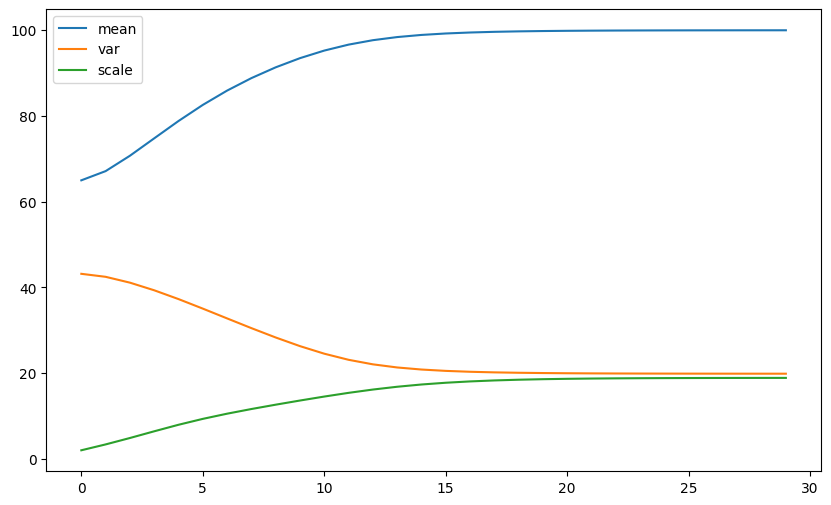

In [44]:
plt.figure(figsize=(10,6))
plt.plot(conv_df["updated_mean"].values, label="mean")
plt.plot(conv_df["updated_var"].values, label="var")
plt.plot(conv_df["updated_scale"].values, label="scale")
plt.legend();